In [1]:
import torch
from torch.utils.data import DataLoader
from torch.utils.data import Dataset
import pandas as pd
import os
from PIL import Image
from torchvision import transforms
import matplotlib.pyplot as plt
import numpy as np



In [6]:


# Cargar metadata completo
metadata = pd.read_csv("../data/metadata.csv")



In [9]:
# Seleccionar subconjunto balanceado o aleatorio
metadata_sample = (
    metadata
    .groupby("label_bin", group_keys=False)
    .apply(lambda x: x.sample(n=40, random_state=42))  # ejemplo: 50 por clase
    .reset_index(drop=True)
)

# metadata_sample.to_csv("metadata_sample_01.csv", index=False)
print(f"Metadata reducido a {len(metadata_sample)} muestras.")

Metadata reducido a 80 muestras.


C:\Users\tguev\AppData\Local\Temp\ipykernel_30348\1084581153.py:5: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: x.sample(n=40, random_state=42))  # ejemplo: 50 por clase


In [71]:
class InVolcDataset(Dataset):
    def __init__(self, metadata_csv, root_dir="../data", transform=None):
        self.data = pd.read_csv(metadata_csv)
        self.root_dir = root_dir
        self.transform = transform

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        # 1) Selección de fila en el CSV por índice
        row = self.data.iloc[idx]

        # 2) Construcción de la ruta absoluta a la imagen (root_dir + img_path)
        img_path = os.path.join(self.root_dir, row["img_path"])

        # 3) Carga de la imagen desde disco (lazy: solo se carga cuando se pide)
        image = Image.open(img_path).convert("RGB")

        # 4) Lectura de la etiqueta y casteo a tensor entero para clasificación
        label_bin = torch.tensor(row["label_bin"], dtype=torch.long)
        label_raw = torch.tensor(row["label_raw"], dtype=torch.long)
        # 5) Transformaciones opcionales (resize, normalización, augmentations)
        if self.transform:
            image = self.transform(image)

        # 6) Retorno con estructura CONSISTENTE
        return {"image": image, "label_raw": label_raw , "label_bin": label_bin, "id": row["id"]}

    def visualizar_muestra(self, idx):
        """
        Visualiza la imagen y sus etiquetas a partir de un índice.
        - idx: índice entero dentro del dataset
        """
        if idx < 0 or idx >= len(self):
            print(f"Índice fuera de rango (0 - {len(self)-1})")
            return

        sample = self[idx]
        image = sample["image"]
        label_bin = sample["label_bin"].item()
        label_raw = sample["label_raw"].item()


        # Convertir tensor a imagen para mostrar
        if isinstance(image, torch.Tensor):
            image_np = image.permute(1, 2, 0).numpy()
        else:
            image_np = np.array(image)

        # Mostrar imagen
        plt.figure(figsize=(6, 6))
        plt.imshow(image_np)
        plt.axis("off")
        plt.title(f"Índice: {idx}\nLabel bin: {label_bin} \nLabel raw: {label_raw}")
        plt.show()

        # imprimir tamaño de la imagen
        print(f"Tamaño de la imagen: {image.shape}")

In [72]:
transform = transforms.Compose([
    # transforms.Resize((256, 256)),
    transforms.ToTensor(),
])

dataset = InVolcDataset(metadata_csv= "../data/metadata_sample_01.csv", transform=transform)
loader = DataLoader(dataset,
                    batch_size=4,
                    num_workers= os.cpu_count(),
                    shuffle=True)

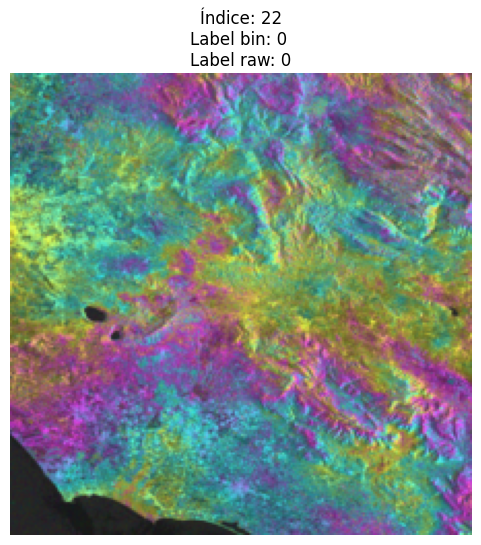

Tamaño de la imagen: torch.Size([3, 224, 224])


In [73]:
# Ejemplo de visualización usando el dataset
dataset.visualizar_muestra(22)

In [74]:
# Añadir una nueva columna sin valores iniciales
metadata_sample["nueva_columna"] = pd.NA

# Sobrescribir el archivo CSV
metadata_sample.to_csv("../data/metadata_sample_01.csv", index=False)
print("Archivo sobrescrito con la nueva columna vacía.")



Archivo sobrescrito con la nueva columna vacía.


In [75]:
# Cambiar el nombre de la columna 'nueva_columna' a 'columna_modificada'
metadata_sample = metadata_sample.rename(columns={"nueva_columna": "subset"})

# Sobrescribir el archivo CSV
metadata_sample.to_csv("../data/metadata_sample_01.csv", index=False)
print("Nombre de la columna modificado y archivo sobrescrito.")

Nombre de la columna modificado y archivo sobrescrito.


In [78]:
from helper_functions import split_metadata
metadata_sample = split_metadata()

División completada:
  Train: 64 muestras
  Test:  16 muestras
  Archivo guardado en: ../data/metadata_sample_01.csv


In [80]:
test_df = metadata_sample.query("subset == 'test'")

          id                img_path        mask_path  label_raw  label_bin  \
7    13823_5   InSAR_img/13823_5.png              NaN          0          0   
10   12210_1   InSAR_img/12210_1.png              NaN          0          0   
14   14480_3   InSAR_img/14480_3.png              NaN          0          0   
18    8020_1    InSAR_img/8020_1.png              NaN          0          0   
20    6073_4    InSAR_img/6073_4.png              NaN          0          0   
22    4185_5    InSAR_img/4185_5.png              NaN          0          0   
28  16489_15  InSAR_img/16489_15.png              NaN          0          0   
38  16111_15  InSAR_img/16111_15.png              NaN          0          0   
43       694       InSAR_img/694.png     mask/694.png          3          1   
48     16914     InSAR_img/16914.png   mask/16914.png          1          1   
53     16864     InSAR_img/16864.png   mask/16864.png          3          1   
57      1044      InSAR_img/1044.png    mask/1044.pn

In [6]:
metadata_sample = pd.read_csv("metadata_sample_01.csv")
metadata_sample = pd.read_csv("metadata_sample_01.csv")

# label_bin = 1 si label_raw >= 2, si no 0
metadata_sample["label_bin"] = (metadata_sample["label_raw"] >= 1).astype(int)

metadata_sample.to_csv("metadata_sample_01.csv", index=False)

